In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.5)
sns.set_palette(sns.color_palette("deep"))
#sns.set_theme(style="whitegrid")  # Equivalent to seaborn-whitegrid
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
#plt.style.use('seaborn-whitegrid')

## Define $z_k$
$z_k$ is inspired from the penalty on model complexity
$$z_{k} = (\frac{n_{p}-8}{a} + \frac{n_{d}}{b} + \frac{n_{s}}{c})_{k}$$

## Proposal density for adding new degrees of freedom
$$q(k'|k) = \frac{sigmoid( -z_{k'})}{sigmoid( -z_{k})}= \frac{1+\exp(z_k)}{1+\exp(z_{k'})}; \quad\quad k<k'$$

In [3]:
a = [1,2,3,4,5]
b = a.remove(4)
a, b

([1, 2, 3, 5], None)

In [4]:
# Define Sigmoid function
def sigmoid(x):
    return 1.0/(1.0+np.exp(-x))

In [22]:
list_zk = []
list_zk_prop = []
def zk(npar, nd, ns):
    a,b,c = 2,4,8
    prior_par = (npar-8)/a
    prior_dec = nd/b          
    prior_ssm = ns/c
    prior = prior_par + prior_dec + prior_ssm
    return prior

def prop_add(np1, nd1, ns1, np2, nd2, ns2):

    zk1 = zk(np1, nd1, ns1)
    zk2 = zk(np2, nd2, ns2)
    list_zk.append(zk1)
    list_zk_prop.append(zk2)
    q21 = sigmoid(-zk2)/sigmoid(-zk1)
    return q21

## Proposal density for removing degrees of freedom
$$q(k'|k) = \frac{sigmoid( z_{k'})}{sigmoid( z_{k})}= \frac{1+\exp(-z_{k})}{1+\exp(-z_{k'})}; \quad\quad k>k' $$

In [11]:
def prop_rem(np1, nd1, ns1, np2, nd2, ns2):

    zk1 = zk(np1, nd1, ns1)
    zk2 = zk(np2, nd2, ns2)
    print(zk1 > zk2)
    q21 = (sigmoid(zk1)/sigmoid(zk2))
    return q21

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


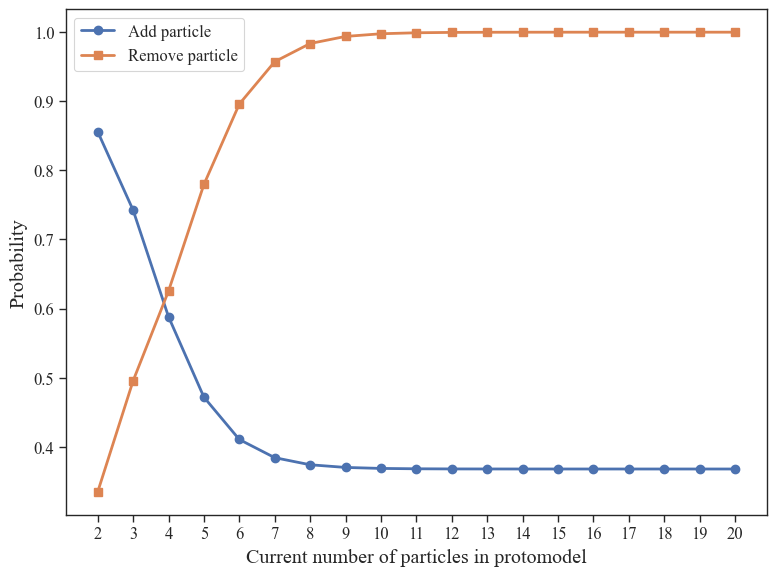

In [32]:
n_par = np.arange(2,21)

nd1 = 1
ns1 = 1
nd2 = nd1 + 2
ns2 = ns1 + 2
prob_list_add, prob_list_rem = [],[]
deg_of_freedom = []

#example case: Adding/removing a particle with 2 extra decay modes and 2 extra prod modes 
for np1 in n_par:
    np2 = np1 + 1 
    
    prob_add = prop_add(np1, nd1, ns1, np2, nd2, ns2)
    #if np1 == 20: prob_add = 0
    prob_list_add.append(prob_add)
    
    deg_of_freedom.append(np1 + nd1 + ns1)

    prob_rem = prop_rem(np1, nd1, ns1, np2, nd2, ns2)
    #if np1 == 1: prob_rem = 0
    #prob_rem = 1- prob_add
    prob_list_rem.append(prob_rem)

    #updating decay and prod modes
    #nd1 = nd1 + 1
    #ns1 = ns1 + 1
    nd1 = nd2
    ns1 = ns2
    nd2 = nd1 + 1
    ns2 = ns1 + 2
   
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(n_par, prob_list_add, 'o-', label='Add particle', linewidth=2, markersize=6)
ax.plot(n_par, prob_list_rem, 's-', label='Remove particle', linewidth=2, markersize=6)
ax.set_xticks(ticks=n_par)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Current number of particles in protomodel")
ax.set_ylabel("Probability")
ax.legend(fontsize=12, loc="best", frameon=True)
#plt.title("Prob to add/remove particle")
plt.tight_layout()
plt.show()

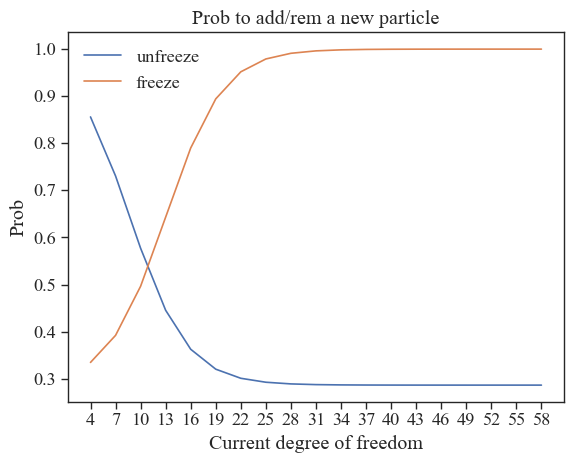

In [19]:
plt.plot(deg_of_freedom, prob_list_add, label='unfreeze')
plt.plot(deg_of_freedom, prob_list_rem, label='freeze')
#plt.plot(n_par, , label='freeze')
plt.xticks(ticks=deg_of_freedom)
plt.xlabel("Current degree of freedom")
plt.ylabel("Prob")
plt.legend()
plt.title("Prob to add/rem a new particle")
plt.show()

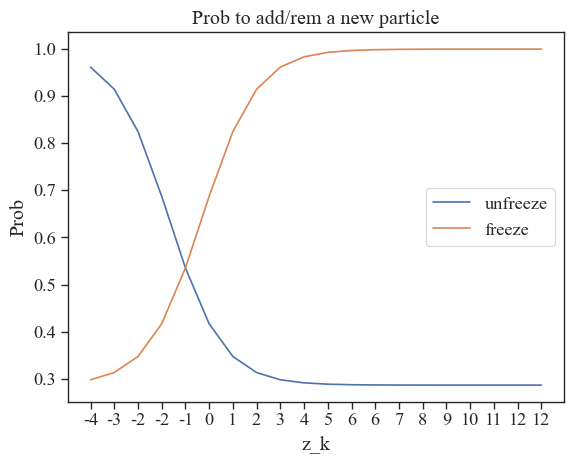

In [161]:
list_zk = np.array(list_zk)
list_zk_prop = np.array(list_zk_prop)

def

plt.plot(list_zk, prob_list_add, label='unfreeze')
plt.plot(list_zk, prob_list_rem, label='freeze')
#plt.plot(n_par, , label='freeze')
plt.xticks(ticks=list_zk,labels=[f'{tick:.0f}' for tick in list_zk])
plt.xlabel("z_k")
plt.ylabel("Prob")
plt.legend()
plt.title("Prob to add/rem a new particle")
plt.show()

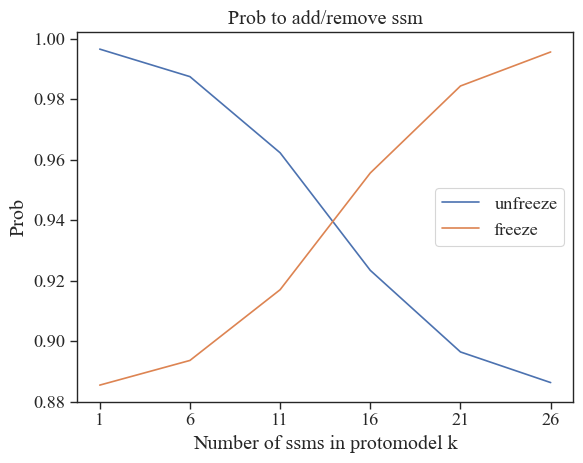

In [121]:
n_br = np.arange(1,20)
n_ssm = np.arange(1,30,5)
np1 = 2
nd1 = 1
np2 = np1
nd2 = nd1
prob_list_add = []
prob_list_rem = []

#example case: Adding/removing a prod mode
for ns1 in n_ssm:
    ns2 = ns1 + 1  
    
    prob_add = prop_add(np1, nd1, ns1, np2, nd2, ns2)
    prob_list_add.append(prob_add)
    deg_of_freedom.append(np1 + nd1 + ns1)

    prob_rem = prop_rem(np1, nd1, ns1, np2, nd2, ns2)
    prob_list_rem.append(prob_rem)

    #updating num_par and decay modes
    np1 = np1 + 1
    np2 = np1
    nd1 = nd1 + 1
    nd2 = nd1

plt.plot(n_ssm, prob_list_add, label='unfreeze')
plt.plot(n_ssm, prob_list_rem, label='freeze')
plt.xticks(ticks=n_ssm)
plt.xlabel("Number of ssms in protomodel k")
plt.ylabel("Prob")
plt.legend()
plt.title("Prob to add/remove ssm")
plt.show()


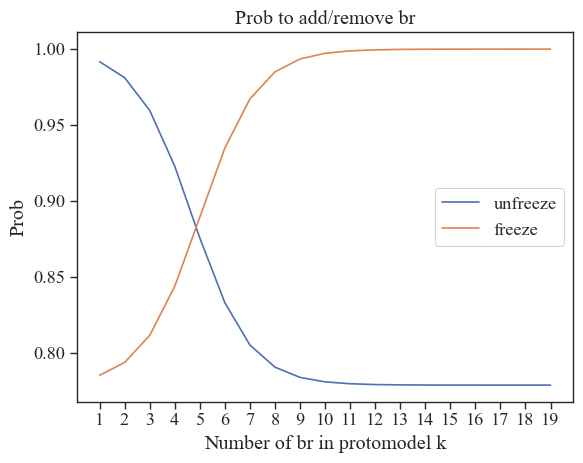

In [122]:
n_br = np.arange(1,20)
n_ssm = np.arange(1,30,5)

np1 = 2
ns1 = 2
np2 = np1
ns2 = ns1
prob_list_add = []
prob_list_rem = []

#example case: Adding/removing a decay mode
for nd1 in n_br:
    nd2 = nd1 + 1  
    
    prob_add = prop_add(np1, nd1, ns1, np2, nd2, ns2)
    prob_list_add.append(prob_add)
    deg_of_freedom.append(np1 + nd1 + ns1)

    prob_rem = prop_rem(np1, nd1, ns1, np2, nd2, ns2)
    prob_list_rem.append(prob_rem)

    #updating num_par and prod modes
    np1 = np1 + 1
    np2 = np1
    ns1 = ns1 + 1
    ns2 = ns1

plt.plot(n_br, prob_list_add, label='unfreeze')
plt.plot(n_br, prob_list_rem, label='freeze')
plt.xticks(ticks=n_br)
plt.xlabel("Number of br in protomodel k")
plt.ylabel("Prob")
plt.legend()
plt.title("Prob to add/remove br")
plt.show()

### Going from k to k'
Let $k<k'$. We want to propose a move from $k \rightarrow k'$ by adding a new particle. Then,
$$q(k'|k) = q(k'|k)_{add} = \frac{sigmoid( -z_{k'})}{sigmoid( -z_{k})}$$
and
$$q(k|k') = q(k|k')_{rem} = \frac{sigmoid( z_{k'})}{sigmoid( z_{k})}$$

### Acceptance Probability
$\\$ New mass: $m_{k+1} = m_{LSP} + (maxmass - m_{LSP})*m_r; \quad m_r \sim Uni[0, 1]; \quad p(m_r) = I_{[0.1]}; |J|_{m} = (maxmass - m_{LSP})$
$\\$ New ssm: $s_{k+1} = s_{r}; \quad s_{r} \sim LogNorm(1.0,1.0); \quad p(s_r) = LogNorm(s_r; 1,1); $
$\\$ New br: $b_{k+1} = b_{r}; \quad b_{r} \sim Gauss(1/dc,\sqrt{0.5/dc}); \quad dc = \text{Number of open decay channels}$
$\\ p(b_r) = Gauss(b_{r}; 1/dc,\sqrt{0.5/dc}); \quad |J|_{br} = 1, \text{if normalized else} |J|_{br} = 1/BR_{tot}$
$$\alpha = min(1, \frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)} \frac{\pi(\theta'_{k'}|k')\pi_{k'}}{\pi(\theta_{k}|k)\pi_{k}}\frac{q(k|k')_{rem}}{p(m_r)p(s_r)p(b_r)q(k'|k)_{add}}|J|_{sr})$$

##### Removing degrees of freedom
$m_r = (m_{k+1} - m_{LSP})/(maxmass - m_{LSP}); p(m_r) = I_{[0,1]}); |J|_m = \partial m_r/\partial m_{k+1} = 1/(maxmass - m_{LSP})$
$$\alpha = min(1, \frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)} \frac{\pi(\theta'_{k'}|k')\pi_{k'}}{\pi(\theta_{k}|k)\pi_{k}}\frac{q(k|k')_{add}p(m_r)p(s_r)p(b_r)}{q(k'|k)_{rem}}|J|_{sr})$$

## Adding only ssm
We want to propose a move from $k \rightarrow k'$ by adding a new ssm.
$\\$ Prob to change existing ssm = $0.25$ (as in the code currently)
$\\$ Prob to add new ssm = $0.25*0.2$
$\\$ Prob to rem ssm = $0.25*0.8*0.1$

$$q(k'|k)_{addssm} = 0.25*0.2*q(k'|k)_{add} $$
$$q(k|k')_{remssm} = 0.25*0.8*0.1*q(k|k')_{rem} $$

$$\alpha = min(1, \frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)} \frac{\pi(\theta'_{k'}|k')\pi_{k'}}{\pi(\theta_{k}|k)\pi_{k}}\frac{0.8*0.1*q(k|k')_{rem}}{0.2*p(s_r)q(k'|k)_{add}}|J|_{sr})$$

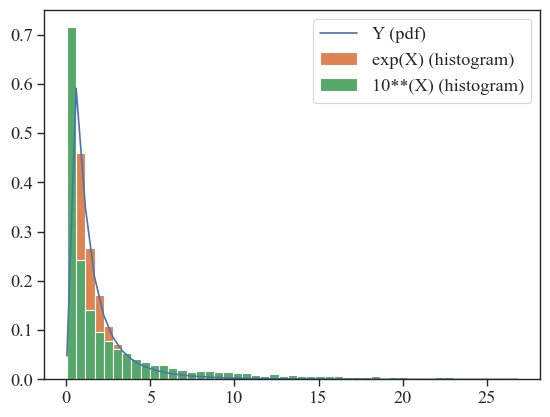

In [136]:
from scipy.stats import norm, lognorm
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
mu, sigma = 0.0, 1.0
X = norm(loc=mu, scale=sigma)
Y = lognorm(s=sigma, scale=np.exp(mu))
x = np.linspace(*X.interval(0.999))
y = Y.rvs(size=10000)

x1 = X.rvs(size=10000)
y1 = np.linspace(*Y.interval(0.999))
#y1 = np.linspace(10**(-2), 10**(2), 10000)

#ax.plot(x, X.pdf(x), label='X (pdf)')
#ax.hist(np.log(y), density=True, bins=x, label='log(Y) (histogram)')

ax.plot(y1, Y.pdf(y1), label='Y (pdf)')
ax.hist(np.exp(x1), density=True, bins=y1, label='exp(X) (histogram)')
ax.hist(10**(x1), density=True, bins=y1, label='10**(X) (histogram)')
ax.legend()
plt.show()

### Adding only new decay modes
We want to propose a move from $k \rightarrow k'$ by adding a new ssm.
$\\$ Prob to change existing decay modes/br = $0.2$
$\\$ Prob to add/change decay modes = $0.2*0.9$
$\\$ Prob to close decay modes = $0.2* (0.05 \text{ (keep only one decay mode)} + 0.05 \text{ (close current decay mode)})$

$$q(k'|k)_{adddec} = 0.2*0.9*q(k'|k)_{add} $$
$$q(k|k')_{remsdec} = 0.2*0.1*q(k|k')_{rem} $$

$$\alpha = min(1, \frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)} \frac{\pi(\theta'_{k'}|k')\pi_{k'}}{\pi(\theta_{k}|k)\pi_{k}}\frac{0.1*q(k|k')_{rem}}{0.9*p(b_r)q(k'|k)_{add}})$$

## Chain for proposal density
1. Take move type - unfreezing, freezing, chaging ssms, br, mass
2. Do the proposed changes
3. If dim changes, check with q(k'|k) -> accept/reject move
4. Carry forward the information to the acceptance probabilty stage

### Questions
What is the prior on parameters $\pi(\theta_k|k$)? Should we take them into account too?
$\\$ Suppose $\theta_{1} = (m_1, s_1, b_1), \theta_{2} = (m_1, s_1, b_1, m_2, s_2, b_2)$. If they are independent priors, then 
$$\frac{\pi(\theta_2|2)}{\pi(\theta_1|1)} = \pi(m_2)\pi(s_2)\pi(b_2)\quad ?$$ 
$\\$ Suppose we change only the mass in $\theta_1$ and not add any new degrees of freedom. Then,
$$\frac{\pi(\theta_2|1)}{\pi(\theta_1|1)} = \frac{\pi(m_2)}{\pi(m_1)}\quad ?$$ 

In that case, should the priors follow similar to how we propose new parameters, i.e $\pi(m_r) \sim Uni[minmass, maxmass]$, etc. ?

## Changing model
Model at step i: manipulator.M; Ex:[X1Z, X1W]
$\\$
Propose model at step i+1: manipulator.propose_model

#### Move 1: Unfreezing a particle
Propose unfreezing of X2Z
$\\$-> Initialize mass of X2Z:
$\\ \quad$    -> Draw random number $m_r \sim Uni[0,1]$
$\\ \quad$    -> $(m_{X1Z}, m_{X1W}, m_r) \rightarrow (m_{X1Z}, m_{X1W}, m_{X2Z}); m_{X2Z} = m_{X1Z} + (m_{max} - m_{X1Z})m_r$ 
$\\ \quad$  -> $|J|^{un}_{m_{X2Z}} = \partial m_{X2Z}/ \partial m_{r} = m_{max} - m_{X1Z}$
$\\ \quad$ -> $p(m_r) = I_{[0,1]}$

$\\$
$\\\\$-> Initialize decays of X2Z:
$\\ \quad$    -> Draw random number $b_r \sim Gauss(1/n_{dc},\sqrt{0.5/n_{dc}})$ for each decay channel
$\\ \quad$    -> $(\{b_{X1W}\}, \{b_r\}) \rightarrow (\{b_{X1W}\}, \{b_{X2Z}\}); b_{X2Z} = b_{r}$
$\\ \quad$  -> $|J|^{un}_{b_{X2Z}} = \partial b_{X2Z}/ \partial b_{r} = 1.0$
$\\ \quad$ -> $p(b_r) = Gauss(b_r|1/n_{dc},\sqrt{0.5/n_{dc}}) $

$\\$
$\\\\$-> Initialize prod modes of X2Z:
$\\ \quad$    -> Draw random number $s_r \sim Lognorm(1.0,\sigma)$ for each prod mode
$\\ \quad$    -> $(\{s_{X1W}\}, \{s_r\}) \rightarrow (\{s_{X1W}\}, \{s_{X2Z}\}); s_{X2Z} = s_{r}$
$\\ \quad$  -> $|J|^{un}_{s_{X2Z}} = \partial s_{X2Z}/ \partial s_{r} = 1.0$
$\\ \quad$ -> $p(s_r) = Lognorm(s_r|1.0,\sigma) $

$\\$
$\\\\$-> Check with probability to unfreeze new degrees of freedom:
$$q_{add}(i\rightarrow i+1) = \frac{sigmoid( -z_{i+1})}{sigmoid( -z_{i})}= \frac{1+\exp(z_i)}{1+\exp(z_{i+1})}; \quad\quad dim(i)<dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q(i\rightarrow i+1)$, reject unfreezing of X2Z, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{un} = 1$
$\\ \quad$    ->else, accept unfreezing of X2Z, calculate the total proposal ratio of the move

$$ q_{un} = \frac{q_{rem}(i+1 \rightarrow i)}{q_{add}(i\rightarrow i+1)} \frac{1}{p(m_r)p(b_r)p(s_r)}|J|^{un}_{m_{X2Z}}$$

#### Move 2: Freezing a particle
Propose freezing of X1W
$\\$-> Remove mass of X1W: 
$\\ \quad$    -> $(m_{X1Z}, m_{X1W}) \rightarrow (m_{X1Z}, m_{r}); m_{X1W} = m_{X1Z} + (m_{max} - m_{X1Z})m_r$ 
$\\ \quad$  -> $|J|^{fr}_{m_{X1W}} = \partial m_{r}/ \partial m_{X_{X1W}} = 1/(m_{max} - m_{X1Z})$
$\\ \quad$ -> $p(m_r) = I_{[0,1]} \quad m_r \sim Uni[0,1]$

$\\$
$\\\\$-> Remove decays of X1W:
$\\ \quad$    -> $  (\{b_{X1W}\}) \rightarrow (\{b_{r}\}) ; b_{X1W} = b_{r}$
$\\ \quad$  -> $|J|^{fr}_{b_{X1W}} = \partial b_{r}/ \partial b_{X1W} = 1.0$
$\\ \quad$ -> $p(b_r) = Gauss(b_r|1/n_{dc},\sqrt{0.5/n_{dc}}) $

$\\$
$\\\\$-> Initialize prod modes of X1W:
$\\ \quad$    -> $(\{s_{X1W}\}) \rightarrow (\{s_{r}\}); s_{X1W} = s_{r}$
$\\ \quad$  -> $|J|^{fr}_{s_{X1W}} = \partial s_{r}/ \partial s_{X1W} = 1.0$
$\\ \quad$ -> $p(s_r) = Lognorm(s_r|1.0,\sigma) $

$\\$
$\\\\$-> Check with probability to freeze new degrees of freedom:
$$q_{rem}(i \rightarrow i+1) = \frac{sigmoid( z_{i})}{sigmoid( z_{i+1})}= \frac{1+\exp(-z_{i+1})}{1+\exp(-z_{i})}; \quad\quad dim(i)>dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject freezing of X1W, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{fr} = 1$
$\\ \quad$    ->else, accept freezing of X1W, calculate the total proposal ratio of the move

$$ q_{fr} = \frac{q_{add}(i+1 \rightarrow i)}{q_{rem}(i\rightarrow i+1)} \frac{p(m_r)p(b_r)p(s_r)}{1}|J|^{fr}_{m_{X1W}}$$

#### Move 3: Removing decay of a particle
Propose removing br of X1W
$\\$ -> Chance of keeping only one decay channel $= 0.05  = p(rem)$
$\\$ -> Chance of removing one decay channel $= 0.05 = p(rem)$
$\\$ -> Chance of adding decay channel = $0.9 * (Gauss(0;n_{dc},\sqrt{0.5/n_{dc}}) + 0.1) = p(add)$
$\\ \quad$    -> $  (\{b_{X1W}\}) \rightarrow (\{b_{r}\}) ; b_{X1W} = b_{r}$
$\\ \quad$  -> $|J|^{fr}_{b_{X1W}} = \partial b_{r}/ \partial b_{X1W} = 1.0$
$\\ \quad$ -> $p(b_r) = Gauss(b_r|1/n_{dc},\sqrt{0.5/n_{dc}}) $

$\\$
$\\\\$-> Check with probability to remove degrees of freedom:
$$q_{rem}(i \rightarrow i+1) = \frac{sigmoid( z_{i})}{sigmoid( z_{i+1})}= \frac{1+\exp(-z_{i+1})}{1+\exp(-z_{i})}; \quad\quad dim(i)>dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject removing, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{br} = 1$
$\\ \quad$    ->else, accept removing, calculate the total proposal ratio of the move

$$ q_{br} = \frac{p(add)q_{add}(i+1 \rightarrow i)}{p(rem)q_{rem}(i\rightarrow i+1)} \frac{p(b_r)}{1}$$

$\\$
$\\\\$-> Check with probability to add degrees of freedom:
$$q_{add}(i\rightarrow i+1) = \frac{sigmoid( -z_{i+1})}{sigmoid( -z_{i})}= \frac{1+\exp(z_i)}{1+\exp(z_{i+1})}; \quad\quad dim(i)<dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject adding, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{br} = 1$
$\\ \quad$    ->else, accept removing, calculate the total proposal ratio of the move

$$ q_{br} = \frac{p(rem)q_{rem}(i+1 \rightarrow i)}{p(add)q_{add}(i\rightarrow i+1)} \frac{1}{p(b_r)}$$

#### Move 3: Adding/Removing prod mode of a particle
Propose adding/removing of prod mode of X1W
$\\$-> Chance of adding prod mode =  $0.2*(lognorm(0.0; 1.0,\sigma) + p(rem))$
$\\$-> Chance of removing prod mod = $0.8*0.01 = p(rem)$

$\\ \quad$    -> $(\{s_{X1W}\}) \rightarrow (\{s_{r}\}); s_{X1W} = s_{r}$
$\\ \quad$  -> $|J|^{fr}_{s_{X1W}} = \partial s_{r}/ \partial s_{X1W} = 1.0$
$\\ \quad$ -> $p(s_r) = Lognorm(s_r|1.0,\sigma) $

$\\$
$\\\\$-> Check with probability to remove degrees of freedom:
$$q_{rem}(i \rightarrow i+1) = \frac{sigmoid( z_{i})}{sigmoid( z_{i+1})}= \frac{1+\exp(-z_{i+1})}{1+\exp(-z_{i})}; \quad\quad dim(i)>dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject removing, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{ssm} = 1$
$\\ \quad$    ->else, accept removing, calculate the total proposal ratio of the move

$$ q_{ssm} = \frac{p(add)q_{add}(i+1 \rightarrow i)}{p(rem)q_{rem}(i\rightarrow i+1)} \frac{p(s_r)}{1}$$

$\\$
$\\\\$-> Check with probability to add degrees of freedom:
$$q_{add}(i\rightarrow i+1) = \frac{sigmoid( -z_{i+1})}{sigmoid( -z_{i})}= \frac{1+\exp(z_i)}{1+\exp(z_{i+1})}; \quad\quad dim(i)<dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject adding, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{br} = 1$
$\\ \quad$    ->else, accept removing, calculate the total proposal ratio of the move

$$ q_{ssm} = \frac{p(rem)q_{rem}(i+1 \rightarrow i)}{p(add)q_{add}(i\rightarrow i+1)} \frac{1}{p(s_r)}$$

#### Total proposal ratio
$$ q_{total} = q_{un} * q_{fr} * q_{br} * q_{ssm} $$

#### Acceptance probability
$$\alpha = min(1, \frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)} \frac{\pi_{k'}}{\pi_{k}}q_{total})$$
$$\alpha = min(1, \log{\frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)}} + \log{ \frac{\pi_{k'}}{\pi_{k}}} + \log{q_{total}})

In [177]:
from scipy.stats import uniform
uniform.rvs(0,1/5, size=10)

array([0.18414406, 0.12996548, 0.13512773, 0.12733327, 0.02152883,
       0.07486692, 0.18377057, 0.10275681, 0.10603491, 0.0916723 ])

In [181]:
1 - uniform.cdf(1e-05, 0,1/5)

0.99995

In [195]:
 ssmul = {(1000023, 1000023): 3.6431786432954665, (-1000006, 1000006): 0.16636520394547644}
 #sorted(ssmul.keys())
 ss = {key:ssmul[key] for key in sorted(ssmul)}
 ss

{(-1000006, 1000006): 0.16636520394547644,
 (1000023, 1000023): 3.6431786432954665}

In [197]:
decays = {1000022: {}, 1000023: {(1000022, 25): 0.165577, (1000022, 23): 0.834423}, np.int64(1000025): {(1000023, 23): 0.534635, (1000022, 25): 0.339166, (1000022, 23): 0.126199}, np.int64(1000006): {(1000022, 6): 0.587947, (1000023, 6): 0.412053}}

new_dc = {pid:{dpid:decays[pid][dpid] for dpid in sorted(decays[pid])} for pid in sorted(decays)}
new_dc


{1000006: {(1000022, 6): 0.587947, (1000023, 6): 0.412053},
 1000022: {},
 1000023: {(1000022, 23): 0.834423, (1000022, 25): 0.165577},
 1000025: {(1000022, 23): 0.126199,
  (1000022, 25): 0.339166,
  (1000023, 23): 0.534635}}